# K-Means Cluster Feature Engineering (Task 1)

Engineers categorical cluster tags from the 8 scaled intelligence features by fitting a K-Means model and one-hot encoding each sample's assigned cluster.
These cluster tags are consumed by the multinomial logistic-regression baseline as extra features, alongside the Gaussian noise-augmented intelligence scores.

The KMeans model is fit on the training split only and then used to tag both train and test samples, so no test information leaks into the cluster geometry.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

# Add the parent directory to the system path so we can import preprocess utilities
sys.path.append(os.path.abspath('..'))
from preprocess import clean_raw_data, preprocess_data, rename_columns

# One cluster per multiple-intelligence dimension
DEFAULT_N_CLUSTERS = 8

## Define K-Means Fitting Function

In [2]:
def fit_kmeans(X: pd.DataFrame, n_clusters: int = DEFAULT_N_CLUSTERS, random_state: int = 42) -> KMeans:
    """Fit a K-Means model on the (scaled, noise-augmented) feature matrix."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    kmeans.fit(X)
    return kmeans

## Define Feature Appending Function

In [3]:
def add_cluster_features(X: pd.DataFrame, kmeans: KMeans) -> pd.DataFrame:
    """Append one-hot encoded K-Means cluster tags to the feature matrix.

    Returns a new DataFrame with the original features plus ``cluster_0`` …
    ``cluster_{k-1}`` indicator columns. The index of ``X`` is preserved so the
    result stays aligned with the corresponding labels.
    """
    labels = kmeans.predict(X)
    n_clusters = kmeans.n_clusters

    cluster_cols = [f'cluster_{i}' for i in range(n_clusters)]
    one_hot = pd.DataFrame(
        np.eye(n_clusters, dtype=float)[labels],
        columns=cluster_cols,
        index=X.index,
    )
    return pd.concat([X, one_hot], axis=1)

## Demonstrate Cluster Feature Generation
We load the raw dataset, clean and preprocess it, fit a K-Means model, and append the cluster features.

In [4]:
# Load dataset
dataset_path = '../dataset/dataset_skill_predictor.csv'
df = pd.read_csv(dataset_path)
df = clean_raw_data(df)

if 'Job profession' in df.columns:
    df = rename_columns(df)

X, y, label_encoder = preprocess_data(df)
print(f"Original feature shape: {X.shape}")

# Fit KMeans
kmeans = fit_kmeans(X, n_clusters=DEFAULT_N_CLUSTERS, random_state=42)

# Add cluster features
X_augmented = add_cluster_features(X, kmeans)
print(f"Augmented feature shape: {X_augmented.shape}")
X_augmented.head()

Original feature shape: (3600, 8)


Augmented feature shape: (3600, 16)


,language_skills,musical_ability,physical_prowess,math_and_logic,spatial_awareness,collaboration_skills,self_awareness,sustainability_focus,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7
0,0.400000,0.000000,0.466667,0.733333,0.800000,0.5,0.866667,0.95,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.466667,0.066667,0.466667,0.733333,0.733333,0.5,0.866667,0.95,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.533333,0.133333,0.466667,0.733333,0.666667,0.5,0.866667,0.95,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.600000,0.200000,0.466667,0.733333,0.933333,0.5,0.866667,0.95,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.533333,0.266667,0.466667,0.733333,1.000000,0.5,0.933333,0.95,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Added experiment section: Clustering parameter experiments and visualizations

This section expands K-Means from feature engineering into a clustering experiment. Class labels are not used to fit K-Means; they are used only afterward to measure how well clusters align with the real profession labels.

- `n_clusters`: tested with several values to see how compact and class-aligned the groups become.
- `silhouette_score`: evaluates separation using only feature geometry.
- `adjusted_rand_score`: compares clusters with true professions after clustering is finished.


In [5]:
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

VIS_DIR = './visualizations'
os.makedirs(VIS_DIR, exist_ok=True)

k_values = [4, 6, 8, 10, 12]
cluster_experiment_rows = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X)
    cluster_experiment_rows.append({
        'n_clusters': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(X, cluster_labels),
        'adjusted_rand_index': adjusted_rand_score(y, cluster_labels),
        'normalized_mutual_info': normalized_mutual_info_score(y, cluster_labels),
    })

cluster_experiments = pd.DataFrame(cluster_experiment_rows)
cluster_experiments


,n_clusters,inertia,silhouette,adjusted_rand_index,normalized_mutual_info
0,4,1086.358547,0.190616,0.059331,0.425363
1,6,893.657077,0.210987,0.097278,0.523101
2,8,792.302303,0.207448,0.130758,0.579717
3,10,707.460493,0.211875,0.166291,0.620530
4,12,640.866065,0.224657,0.210427,0.665432


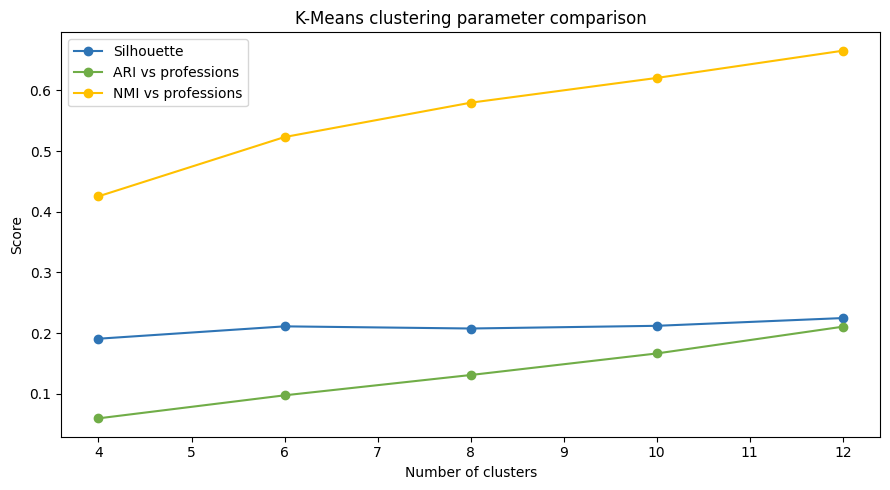

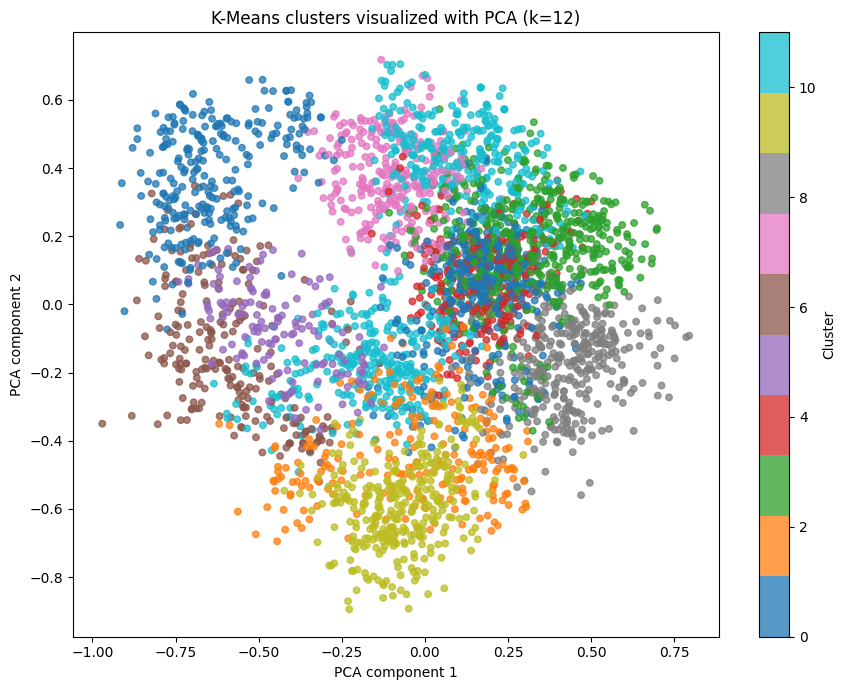

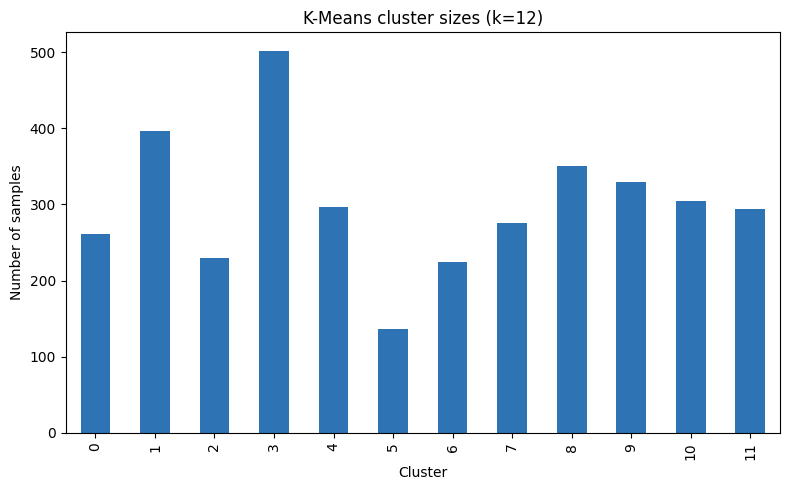

In [6]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(cluster_experiments['n_clusters'], cluster_experiments['silhouette'], marker='o', label='Silhouette', color='#2E74B5')
ax1.plot(cluster_experiments['n_clusters'], cluster_experiments['adjusted_rand_index'], marker='o', label='ARI vs professions', color='#70AD47')
ax1.plot(cluster_experiments['n_clusters'], cluster_experiments['normalized_mutual_info'], marker='o', label='NMI vs professions', color='#FFC000')
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('Score')
ax1.set_title('K-Means clustering parameter comparison')
ax1.legend()
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'kmeans_parameter_comparison.png'), dpi=180)
plt.show()

best_k = int(cluster_experiments.sort_values('silhouette', ascending=False).iloc[0]['n_clusters'])
best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
best_cluster_labels = best_kmeans.fit_predict(X)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=best_cluster_labels, cmap='tab10', s=22, alpha=0.75)
ax.set_title(f'K-Means clusters visualized with PCA (k={best_k})')
ax.set_xlabel('PCA component 1')
ax.set_ylabel('PCA component 2')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'kmeans_pca_clusters.png'), dpi=180)
plt.show()

cluster_sizes = pd.Series(best_cluster_labels).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 5))
cluster_sizes.plot(kind='bar', ax=ax, color='#2E74B5')
ax.set_title(f'K-Means cluster sizes (k={best_k})')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of samples')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'kmeans_cluster_sizes.png'), dpi=180)
plt.show()
